<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/snow_simu/snow_flake3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D  # [NEW] 3Dプロット用

In [75]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation  # [FIX] save_gif で使うのに import 漏れしていた
from scipy.spatial import cKDTree
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D  # [NEW] 3Dプロット用

@dataclass
class ParticleState:
    time: float
    position: np.ndarray      # (dim, n_particle)
    frag: np.ndarray          # (n_particle,)  True = 吸着済み(固定), False = 拡散中(active)


class Particle:
    def __init__(
        self,
        nums=100,
        tmax=100,
        dt=1.0,   # [FIX] dt は移動量に反映されないため、1.0 にしないと無駄にステップ数が増えるだけ
        particle_init_posi_range=[
            [20, 40],
            [20, 40],
            [20, 40]
        ],
        boundary=[
            [0, 100],
            [0, 100],
            [0, 100]
        ]
    ):

        self.n_particle = nums
        self.dim = len(boundary)

        self.time = 0.0
        self.tmax = tmax
        self.dt = dt
        self.t = np.arange(0, tmax + dt, dt)

        self.boundary = [[int(b[0]), int(b[1])] for b in boundary]

        # ------------------------
        # 初期位置
        # ------------------------

        init_position = []

        for rng in particle_init_posi_range:
            init_position.append(
                np.random.randint(rng[0], rng[1], nums)
            )

        self.init_position = np.array(init_position)

        self.init_frag = np.zeros(nums, dtype=bool)

        # ------------------------
        # 時系列データ
        # ------------------------

        self.states = []

        for i, t in enumerate(tqdm(self.t, desc="Allocating states")):

            if i == 0:
                position = self.init_position.copy()
            else:
                position = np.zeros_like(self.init_position)

            self.states.append(
                ParticleState(
                    time=t,
                    position=position,
                    frag=self.init_frag.copy()
                )
            )

    def __repr__(self):
        return (
            f"Particle("
            f"n_particle={self.n_particle}, "
            f"dimension={self.dim}, "
            f"n_step={len(self.states)})"
        )

    def add_active_particles(self, added_position=None, added_time=0):
        """
        既存の粒子集団に、新たな粒子(典型的には最初から吸着済みの「核」)を追加する。

        [FIX] グローバル変数 particle.states を参照していたバグを self.states に修正。
        [NOTE] added_time は現状 self.states[0].time (=シミュレーション開始時刻) を
               想定しています。途中の時刻から粒子を追加する場合、それより前の
               ステップの position 配列サイズと self.n_particle が食い違い
               shape mismatch になるため、その場合は事前に警告します。
        """
        print(f"Old property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")
        print("-----------" * 6)

        added_position = np.array(added_position, dtype=float)
        added_nums = added_position.shape[1]

        if added_time > self.states[0].time:
            print(
                f"[WARNING] added_time={added_time} は開始時刻"
                f"{self.states[0].time} より後です。"
                f"added_time より前のステップは position の配列サイズが"
                f"self.n_particle と食い違うため、update() 実行時にエラーになる"
                f"可能性があります。added_time=0 での利用を推奨します。"
            )

        for state in self.states:  # [FIX] self.states を参照
            if state.time >= added_time:
                state.position = np.concatenate((state.position, added_position), axis=1)
                state.frag = np.concatenate((state.frag, np.ones(added_nums, dtype=bool)))

        self.n_particle = self.n_particle + added_nums
        print(f"Updated property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")


    def update_loop(self, step: int, dx_range: list = [-1, 1], dy_range: list = [-1, 1],
                    dz_range: list = [-1, 1], fix_inactive=True):  # [NEW] dz_range を追加
        if step == 0:
            return

        state = self.states[step]
        _state = self.states[step - 1]

        # [FIX] 前ステップの吸着状態(frag)をこのステップに引き継ぐ。
        state.frag = _state.frag.copy()

        # 1. 移動量の生成
        dx = np.random.randint(dx_range[0], dx_range[1] + 1, self.n_particle)
        dy = np.random.randint(dy_range[0], dy_range[1] + 1, self.n_particle)
        dz = np.random.randint(dz_range[0], dz_range[1] + 1, self.n_particle)  # [NEW] z方向の移動量

        # 2. 吸着済み(frag=True)粒子の移動を固定
        if fix_inactive:
            dx[_state.frag] = 0
            dy[_state.frag] = 0
            dz[_state.frag] = 0  # [NEW]

        # 3. 位置の仮更新
        state.position[0] = _state.position[0] + dx
        if self.dim >= 2:
            state.position[1] = _state.position[1] + dy
        if self.dim >= 3:
            state.position[2] = _state.position[2] + dz  # [NEW] z座標の更新

        # ---------------------------------------------------------
        # 4. 境界(壁)での跳ね返り処理
        # ---------------------------------------------------------

        xmin, xmax = self.boundary[0][0], self.boundary[0][1]

        under_x = state.position[0] < xmin
        if np.any(under_x):
            state.position[0][under_x] = 2 * xmin - state.position[0][under_x]

        over_x = state.position[0] > xmax
        if np.any(over_x):
            state.position[0][over_x] = 2 * xmax - state.position[0][over_x]

        if self.dim >= 2:
            ymin, ymax = self.boundary[1][0], self.boundary[1][1]

            under_y = state.position[1] < ymin
            if np.any(under_y):
                state.position[1][under_y] = 2 * ymin - state.position[1][under_y]

            over_y = state.position[1] > ymax
            if np.any(over_y):
                state.position[1][over_y] = 2 * ymax - state.position[1][over_y]

        # [NEW] --- Z軸の壁判定と跳ね返り(3次元の場合) ---
        if self.dim >= 3:
            zmin, zmax = self.boundary[2][0], self.boundary[2][1]

            under_z = state.position[2] < zmin
            if np.any(under_z):
                state.position[2][under_z] = 2 * zmin - state.position[2][under_z]

            over_z = state.position[2] > zmax
            if np.any(over_z):
                state.position[2][over_z] = 2 * zmax - state.position[2][over_z]
    def update(self, dx_range: list = [-1, 1], dy_range: list = [-1, 1],
              dz_range: list = [-1, 1], fix_inactive=True):  # [NEW] dz_range を追加
        """全ステップにわたってランダムウォークを適用する"""
        for i in tqdm(range(len(self.states)), desc="Updating Simulation"):
            self.update_loop(
                step=i, dx_range=dx_range, dy_range=dy_range,
                dz_range=dz_range, fix_inactive=fix_inactive  # [NEW]
            )
            self.absorp_judge(step=i)

            if not np.any(~self.states[i].frag):
                print(f"iter {i}: 全粒子が吸着済みのため終了します")
                break
    def absorp_judge(self, step):
        """
        active粒子が inactive(吸着済み)粒子と上下左右(4近傍)で隣接したら吸着する。

        [FIX] チェビシェフ距離(p=inf)だと斜め方向(dx=1,dy=1)も距離1と
        判定されて吸着してしまうため、マンハッタン距離(p=1)に変更。
        マンハッタン距離<=1 は (dx,dy) が (0,0),(1,0),(-1,0),(0,1),(0,-1) の
        場合のみ成立し、斜め(1,1)は距離2になるため自動的に除外される。
        """
        state = self.states[step]
        active = ~state.frag
        inactive = state.frag

        if not np.any(inactive) or not np.any(active):
            return

        active_pos = state.position[:, active].T      # (n_active, dim)
        inactive_pos = state.position[:, inactive].T   # (n_inactive, dim)

        tree = cKDTree(inactive_pos)
        # p=1 -> マンハッタン距離での最近傍距離（4近傍判定）
        dist, _ = tree.query(active_pos, k=1, p=1)

        absorbed = dist <= 1

        state.frag[active] = absorbed

    def get_state(self, step):
        return self.states[step]
    def plot(
        self,
        step=0,
        figsize=(3, 3),
        dpi=150,
        particle_size=1,
        save_path=None,
        show=True,
        elev=20,     # [NEW] 3D視点の仰角
        azim=45,     # [NEW] 3D視点の方位角
    ):

        state = self.states[step]

        if self.dim == 2:

            fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

            ax.set_xlim(self.boundary[0])
            ax.set_ylim(self.boundary[1])

            active = ~state.frag
            inactive = state.frag

            scat_active = ax.scatter(
                state.position[0][active],
                state.position[1][active],
                s=particle_size,
                facecolors="#f58a8a",
                edgecolors="#b41f1f",
                alpha=0.8,
                lw=0.5,
                label="Active",
                zorder=2,
            )

            scat_absorbed = ax.scatter(
                state.position[0][inactive],
                state.position[1][inactive],
                s=particle_size,
                facecolors="#14d8f1",
                edgecolors="#3877ec",
                alpha=0.9,
                marker="s",
                lw=0.5,
                label="Absorbed",
                zorder=3,
            )

            ax.set_xlabel("x")
            ax.set_ylabel("y")
            title = ax.set_title(f"$t={state.time:.2f}$")
            ax.set_aspect("equal")
            ax.tick_params(direction="in")
            ax.legend(frameon=False)
            ax.grid(False)

            fig.tight_layout()

            if save_path is not None:
                fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

            if show:
                plt.show()

            return fig, ax, scat_active, scat_absorbed, title

        elif self.dim == 3:
            # [NEW] 3次元プロット対応
            fig = plt.figure(figsize=figsize, dpi=dpi)
            ax = fig.add_subplot(111, projection="3d")

            ax.set_xlim(self.boundary[0])
            ax.set_ylim(self.boundary[1])
            ax.set_zlim(self.boundary[2])

            active = ~state.frag
            inactive = state.frag

            scat_active = ax.scatter(
                state.position[0][active],
                state.position[1][active],
                state.position[2][active],
                s=particle_size,
                facecolors="#f58a8a",
                edgecolors="#b41f1f",
                alpha=0.8,
                lw=0.5,
                label="Active",
            )

            scat_absorbed = ax.scatter(
                state.position[0][inactive],
                state.position[1][inactive],
                state.position[2][inactive],
                s=particle_size,
                facecolors="#14d8f1",
                edgecolors="#3877ec",
                alpha=0.9,
                marker="s",
                lw=0.5,
                label="Absorbed",
            )

            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.set_zlabel("z")
            title = ax.set_title(f"$t={state.time:.2f}$")
            ax.view_init(elev=elev, azim=azim)  # [NEW] 視点を設定
            ax.legend(frameon=False)

            fig.tight_layout()

            if save_path is not None:
                fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

            if show:
                plt.show()

            # [NEW] scat_active, scat_absorbed は3Dだと set_offsets が使えないため、
            # save_gif側でこれらを直接使い回さず、都度作り直す設計にする(下記参照)
            return fig, ax, scat_active, scat_absorbed, title

        else:
            raise ValueError(f"未対応の次元です: dim={self.dim}")

    def save_gif(self, filename="simulation.gif", fps=20, figsize=(4, 4), dpi=80,
                particle_size=8, frame_step=5, elev=20, azim=45, rotate=False):
        """
        シミュレーション結果をアニメーション(GIF)として保存する。

        [FIX] 3次元シミュレーションに対応。
        3Dの散布図はoffsetsの直接更新ができないため、毎フレーム ax.cla() で
        描き直す方式にした(2Dのset_offsets方式より低速)。
        rotate=True にすると、フレームごとに視点(azim)を少しずつ回転させる。
        """
        if self.dim not in (2, 3):
            raise ValueError("GIF creation is only supported for 2D/3D simulations.")

        frame_indices = list(range(0, len(self.states), frame_step))
        print(f"Total steps: {len(self.states)}, rendering {len(frame_indices)} frames")

        if self.dim == 2:
            # ------------------------------------------------
            # 2D: 従来通り set_offsets による軽量更新
            # ------------------------------------------------
            fig, ax, scat_active, scat_absorbed, title = self.plot(
                step=0, figsize=figsize, dpi=dpi, particle_size=particle_size, show=False
            )
            ax.legend(frameon=False, loc="upper right")

            def update_frame(idx):
                state = self.states[idx]
                active = ~state.frag
                absorbed = state.frag

                scat_active.set_offsets(np.c_[state.position[0][active], state.position[1][active]])
                scat_absorbed.set_offsets(np.c_[state.position[0][absorbed], state.position[1][absorbed]])
                title.set_text(f"$t={state.time:.2f}$")
                return scat_active, scat_absorbed, title

        else:
            # ------------------------------------------------
            # [NEW] 3D: ax.cla() で毎フレーム描き直す方式
            # ------------------------------------------------
            fig = plt.figure(figsize=figsize, dpi=dpi)
            ax = fig.add_subplot(111, projection="3d")

            def update_frame(idx):
                ax.cla()  # 前フレームの描画をクリア

                state = self.states[idx]
                active = ~state.frag
                inactive = state.frag

                ax.set_xlim(self.boundary[0])
                ax.set_ylim(self.boundary[1])
                ax.set_zlim(self.boundary[2])
                ax.set_xlabel("x")
                ax.set_ylabel("y")
                ax.set_zlabel("z")

                ax.scatter(
                    state.position[0][active],
                    state.position[1][active],
                    state.position[2][active],
                    s=particle_size,
                    facecolors="#f58a8a",
                    edgecolors="#b41f1f",
                    alpha=0.8,
                    lw=0.5,
                    label="Active",
                )
                ax.scatter(
                    state.position[0][inactive],
                    state.position[1][inactive],
                    state.position[2][inactive],
                    s=particle_size,
                    facecolors="#14d8f1",
                    edgecolors="#3877ec",
                    alpha=0.9,
                    marker="s",
                    lw=0.5,
                    label="Absorbed",
                )

                # [NEW] rotate=True ならフレームごとに視点を少しずつ回転
                frame_azim = (azim + idx * 0.5) % 360 if rotate else azim
                ax.view_init(elev=elev, azim=frame_azim)

                ax.set_title(f"$t={state.time:.2f}$")
                ax.legend(frameon=False, loc="upper right")
                return []

        ani = animation.FuncAnimation(
            fig, update_frame, frames=frame_indices, interval=1000 / fps, blit=False
        )

        print(f"Saving GIF to {filename}...")
        ani.save(filename, writer="pillow", fps=fps, dpi=dpi)
        plt.close(fig)
        print("GIF save completed!")
    def make_dataframe(self, step=0):
        """指定したステップの状態をpandas.DataFrameに変換する"""
        state = self.states[step]

        # positionは (dim, n_particle) なので転置して (n_particle, dim) にする
        posi = state.position.T

        # 次元数に応じた列名を作成 (例: 2次元なら ["x", "y"], 3次元なら ["x", "y", "z"])
        columns = ["x", "y", "z"][:self.dim]

        # pandas DataFrameを作成
        df = pd.DataFrame(posi, columns=columns)

        # 吸着状態フラグを追加
        df["is_absorbed"] = state.frag

        return df

    def compute_surface_area(self, step):
        """
        指定ステップにおける吸着済み粒子集合の表面積を計算する。
        (3次元専用。各粒子を単位立方体とみなし、6近傍のうち
        吸着されていない方向の面数を数える)
        """
        if self.dim != 3:
            raise ValueError("表面積計算は現状3次元のみ対応です")

        state = self.states[step]
        inactive = state.frag

        if not np.any(inactive):
            return 0

        # [NEW] 吸着済み粒子の座標を整数タプルのsetにする(高速な近傍存在チェックのため)
        pos = state.position[:, inactive]
        coords = np.round(pos).astype(int).T  # (n_inactive, 3)
        coord_set = set(map(tuple, coords))

        # 6方向の隣接ベクトル
        neighbor_offsets = [
            (1, 0, 0), (-1, 0, 0),
            (0, 1, 0), (0, -1, 0),
            (0, 0, 1), (0, 0, -1),
        ]

        surface_area = 0
        for c in coord_set:
            for dx, dy, dz in neighbor_offsets:
                neighbor = (c[0] + dx, c[1] + dy, c[2] + dz)
                if neighbor not in coord_set:
                    surface_area += 1  # この面は露出している

        return surface_area


    def compute_surface_area_history(self, step_stride=1):
        """
        全ステップ(またはstep_strideおきのステップ)について表面積を計算し、
        時刻の配列と表面積の配列を返す。
        """
        steps = list(range(0, len(self.states), step_stride))
        times = []
        areas = []

        for s in tqdm(steps, desc="Computing surface area"):
            times.append(self.states[s].time)
            areas.append(self.compute_surface_area(s))

        return np.array(times), np.array(areas)

# 3D


In [76]:
particle = Particle(nums = 3_000, tmax =6_000,boundary = [[0, 50], [0, 50],[0,50]],
                    particle_init_posi_range=[[0, 50], [0, 50],[0, 50]])

Allocating states: 100%|██████████| 6001/6001 [00:00<00:00, 78233.36it/s]


In [77]:
n_points = 200
radius = 5
center = np.array([25, 25, 25])

# [NEW] Fibonacci球面配置(黄金角を使い、球面上にほぼ均一に点を配置する)
indices = np.arange(0, n_points, dtype=float) + 0.5

phi = np.arccos(1 - 2 * indices / n_points)              # 緯度方向(0〜π)
golden_angle = np.pi * (3.0 - np.sqrt(5.0))               # 黄金角
theta = golden_angle * indices                             # 経度方向

x_active = center[0] + radius * np.sin(phi) * np.cos(theta)
y_active = center[1] + radius * np.sin(phi) * np.sin(theta)
z_active = center[2] + radius * np.cos(phi)

position_active = np.array([x_active, y_active, z_active])

particle.add_active_particles(added_position=position_active, added_time=0)

Old property n_particle=3000, dimension=3, n_step=6001
------------------------------------------------------------------
Updated property n_particle=3200, dimension=3, n_step=6001


In [78]:
particle.update(fix_inactive= True)


Updating Simulation:  87%|████████▋ | 5245/6001 [00:15<00:02, 338.86it/s]

iter 5245: 全粒子が吸着済みのため終了します


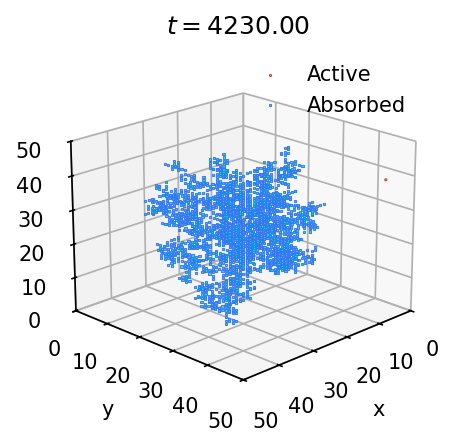

(<Figure size 450x450 with 1 Axes>,
 <Axes3D: title={'center': '$t=4230.00$'}, xlabel='x', ylabel='y', zlabel='z'>,
 Text(0.5, 1.0, '$t=4230.00$'))

In [79]:
particle.plot(step =4230, particle_size= 1)

In [62]:
particle.save_gif(filename="simulation_heat.gif", fps=20, figsize=(4, 4), dpi=80,
                particle_size=8, frame_step=5)

Total steps: 6001, rendering 1201 frames
Saving GIF to simulation_heat.gif...
GIF save completed!


Computing surface area: 100%|██████████| 6001/6001 [01:02<00:00, 96.51it/s] 


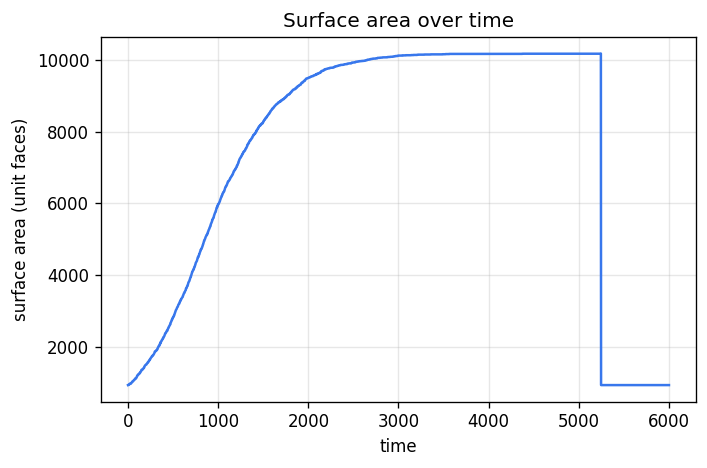

In [81]:
times, areas = particle.compute_surface_area_history(step_stride=1)

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(times, areas, color="#3877ec")
ax.set_xlabel("time")
ax.set_ylabel("surface area (unit faces)")
ax.set_title("Surface area over time")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()